# Week 3 – Model Creation
### Cardiovascular Disease Risk Prediction




In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score



In [7]:
df = pd.read_csv("cardio_cleaned_scaled.csv")
print("Shape of cleaned, scaled dataset:", df.shape)
df.head()

Shape of cleaned, scaled dataset: (68573, 14)


,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,pulse_pressure
0,1.366998,0.453931,-0.847695,-0.999673,-0.138827,-0.537301,-0.394993,-0.31059,-0.237417,0.494626,-0.989598,-0.434502,-1.051783,-1.317580
1,-0.731530,-1.075277,0.761966,0.798090,0.919478,2.408242,-0.394993,-0.31059,-0.237417,0.494626,1.010511,0.309052,1.437914,0.396885
2,-0.731530,0.071629,-0.707724,0.198836,-1.197131,2.408242,-0.394993,-0.31059,-0.237417,-2.021731,1.010511,-0.246486,-0.755820,1.254117
3,1.366998,0.581365,0.552010,1.397344,1.977782,-0.537301,-0.394993,-0.31059,-0.237417,0.494626,1.010511,-0.746511,0.243603,0.396885
4,-0.731530,-1.075277,-1.267607,-1.598927,-2.255436,-0.537301,-0.394993,-0.31059,-0.237417,-2.021731,-0.989598,-0.806887,-0.851221,-0.460348


In [22]:
X = df.drop("cardio", axis=1)
y = df["cardio"]

if y.nunique() > 2:
    print("Target column appears to be scaled. Converting to binary...")
    y = (y >= 0.5).astype(int)
else:
    y = y.astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("\nTarget values:")
print(y_train.value_counts())

X_train: (54858, 13)
X_test : (13715, 13)

Target values:
cardio
0    27716
1    27142
Name: count, dtype: int64


In [16]:
library_model = LogisticRegression(max_iter=1000, random_state=42)

library_model.fit(X_train, y_train)

train_pred = library_model.predict(X_train)
test_pred = library_model.predict(X_test)

library_train_acc = accuracy_score(y_train, train_pred)
library_test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", round(library_train_acc, 4))
print("Test Accuracy :", round(library_test_acc, 4))

Train Accuracy: 0.7279
Test Accuracy : 0.7258


In [17]:
coeffs = pd.Series(library_model.coef_[0], index=X_train.columns).sort_values(key=abs, ascending=False)
print("Feature coefficients (scikit-learn model, sorted by magnitude):")
print(coeffs)

Feature coefficients (scikit-learn model, sorted by magnitude):
ap_hi             0.452516
ap_lo             0.380627
age_years         0.344069
pulse_pressure    0.339013
cholesterol       0.336828
weight            0.336623
bmi              -0.168714
height           -0.122820
active           -0.089177
gluc             -0.063437
alco             -0.053610
smoke            -0.040550
gender           -0.009139
dtype: float64


In [23]:
class CustomLogisticRegression:

    def __init__(self, learning_rate=0.1, n_iterations=2000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -500, 500) 
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=np.float64)
        y = np.asarray(y, dtype=np.float64)
        m, n = X.shape

        self.weights = np.zeros(n)
        self.bias = 0.0

        for i in range(self.n_iterations):
            linear_output = X @ self.weights + self.bias
            y_pred = self._sigmoid(linear_output)

            error = y_pred - y
            dw = (1 / m) * (X.T @ error)
            db = (1 / m) * np.sum(error)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            eps = 1e-15  # avoid log(0)
            cost = -(1 / m) * np.sum(
                y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps)
            )
            self.cost_history.append(cost)

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=np.float64)
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [19]:
scratch_model = CustomLogisticRegression(learning_rate=0.1, n_iterations=2000)
scratch_model.fit(X_train.values, y_train.values)

y_pred_scratch = scratch_model.predict(X_test.values)
scratch_train_acc = accuracy_score(y_train, scratch_model.predict(X_train.values))
scratch_test_acc = accuracy_score(y_test, y_pred_scratch)

print(f"Scratch Logistic Regression — Train Accuracy: {scratch_train_acc:.4f}")
print(f"Scratch Logistic Regression — Test Accuracy:  {scratch_test_acc:.4f}")

Scratch Logistic Regression — Train Accuracy: 0.7281
Scratch Logistic Regression — Test Accuracy:  0.7255


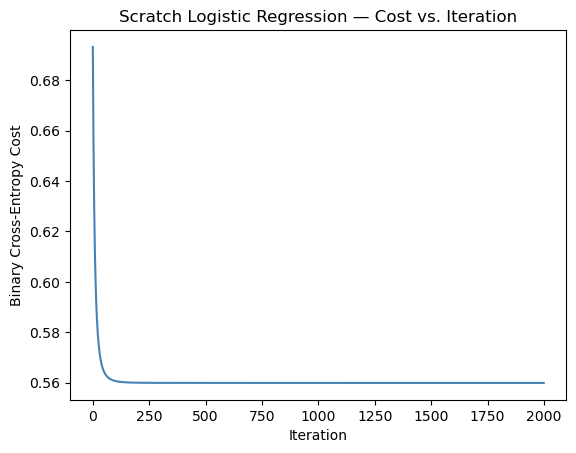

In [24]:
plt.plot(scratch_model.cost_history, color='steelblue')
plt.title('Scratch Logistic Regression — Cost vs. Iteration')
plt.xlabel('Iteration')
plt.ylabel('Binary Cross-Entropy Cost')
plt.show()

In [21]:
comparison = pd.DataFrame({
    'Model': ['scikit-learn LogisticRegression', 'Custom (NumPy) LogisticRegression'],
    'Train Accuracy': [library_train_acc, scratch_train_acc],
    'Test Accuracy': [library_test_acc, scratch_test_acc],
})
comparison

,Model,Train Accuracy,Test Accuracy
0,scikit-learn LogisticRegression,0.727916,0.725775
1,Custom (NumPy) LogisticRegression,0.728062,0.725483
